In [10]:
from importlib import reload
import src.datasets

reload(src.datasets)

<module 'src.datasets' from 'C:\\Users\\dwhip\\PycharmProjects\\chromatintune\\src\\datasets.py'>

In [3]:
from src.utils import one_hot_encode

x = one_hot_encode("ACGTACGT")

print(x.shape)
print(x)

(8, 4)
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [11]:
from src.datasets import SequenceDataset

dataset = SequenceDataset(
    "../data/raw/mock_data.csv"
)

print(len(dataset))

x, y = dataset[0]

print(x.shape)
print(y)

4
torch.Size([4, 10])
tensor(0.8200)


In [12]:
from src.model import SequenceCNN

model = SequenceCNN()

x = x.unsqueeze(0)

print(x.shape)

output = model(x)

print(output)

torch.Size([1, 4, 10])
tensor([[0.1331]], grad_fn=<AddmmBackward0>)


In [13]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

In [14]:
for batch_x, batch_y in dataloader:

    print(batch_x.shape)
    print(batch_y.shape)

    break

torch.Size([2, 4, 10])
torch.Size([2])


In [3]:
import torch

from src.model import SequenceCNN

model = SequenceCNN()

model.load_state_dict(
    torch.load(
        "../models/liver_accessibility_cnn.pth"
    )
)

model.eval()

SequenceCNN(
  (conv1): Conv1d(4, 32, kernel_size=(5,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [4]:
filters = model.conv1.weight.data

print(filters.shape)

torch.Size([32, 4, 5])


In [5]:
filters_np = filters.numpy()

In [6]:
filter_0 = filters_np[0]

print(filter_0)

[[ 0.37951216  0.23157053  0.05200871  0.23829077 -0.71446055]
 [-0.13561535 -0.34660268 -0.6082264  -0.02682539 -0.9832662 ]
 [ 0.04181836 -0.6484259   0.23636763 -0.942676   -0.57564706]
 [-0.45971656 -0.56344324 -0.03908376 -0.26187566  0.25137663]]


In [7]:
print(filter_0.shape)

(4, 5)


In [7]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import use
use("qt5agg")
print(matplotlib.get_backend())

qt5agg


In [2]:
filter_0 = (
    model.conv1.weight.data[0]
    .detach()
    .numpy()
)

print(filter_0.shape)

import matplotlib.pyplot as plt

plt.imshow(filter_0)

plt.show()

NameError: name 'model' is not defined

In [8]:
filter_0 = (
    model.conv1.weight[0]
    .detach()
    .cpu()
    .numpy()
)

print(type(filter_0))
print(filter_0.shape)

<class 'numpy.ndarray'>
(4, 5)


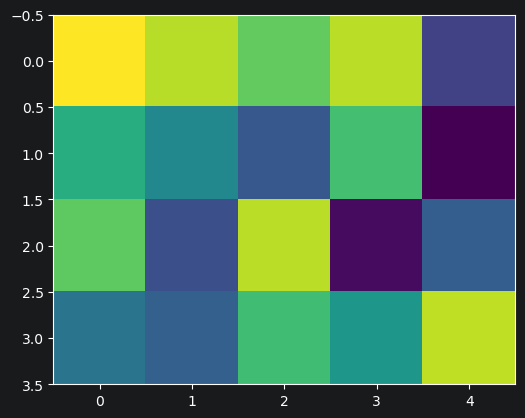

In [9]:
import matplotlib.pyplot as plt

plt.imshow(filter_0)

plt.show()

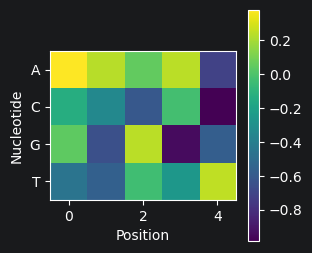

In [10]:
plt.figure(figsize=(3, 3))

plt.imshow(filter_0)

plt.yticks(
    [0, 1, 2, 3],
    ["A", "C", "G", "T"]
)

plt.xlabel("Position")
plt.ylabel("Nucleotide")

plt.colorbar()

plt.show()

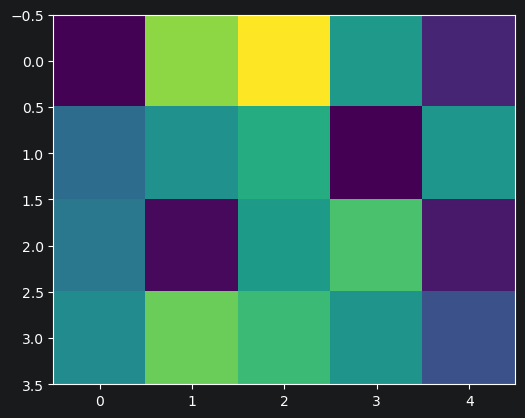

In [1]:
import numpy as np
import matplotlib.pyplot as plt

test = np.random.rand(4, 5)

plt.imshow(test)

plt.show()

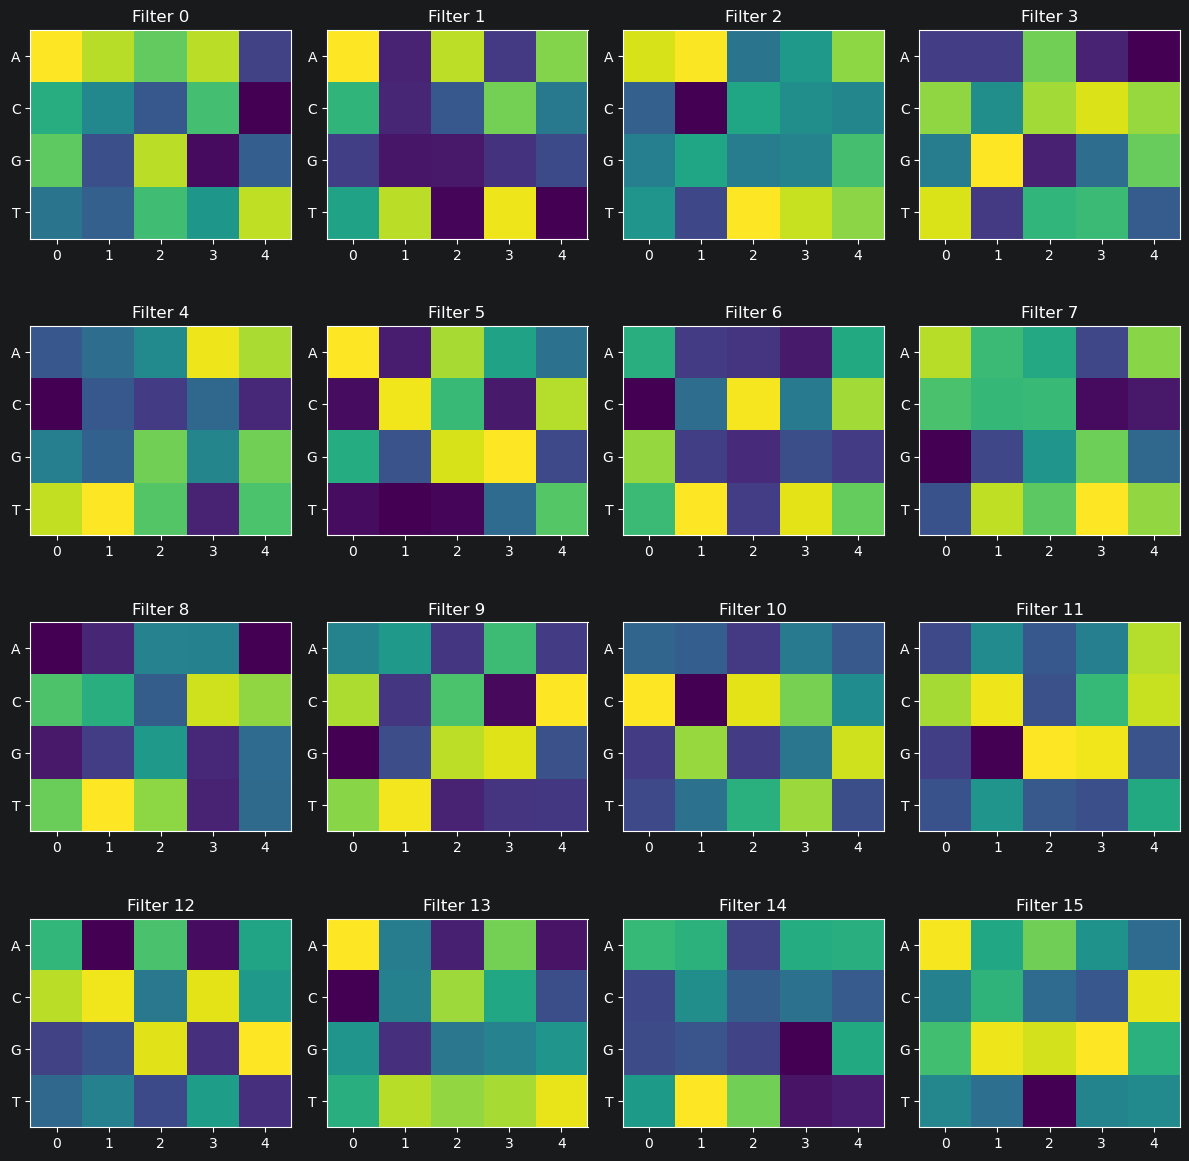

In [11]:
filters_np = (
    model.conv1.weight
    .detach()
    .cpu()
    .numpy()
)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(filters_np[i])

    ax.set_title(f"Filter {i}")

    ax.set_yticks([0, 1, 2, 3])

    ax.set_yticklabels(
        ["A", "C", "G", "T"]
    )

plt.tight_layout()

plt.show()

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:

plt.imshow(filter_0)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(filter_0)

plt.yticks(
    [0, 1, 2, 3],
    ["A", "C", "G", "T"]
)

plt.xlabel("Position")
plt.ylabel("Nucleotide")

plt.colorbar()

plt.show()

In [3]:
pwd

'C:\\Users\\dwhip\\PycharmProjects\\chromatintune\\notebooks'

In [2]:
import pandas as pd

xlsx = pd.ExcelFile(
    "../data/raw/GSE293971_STARR_SEQ_SUPPLEMENTARY.xlsx"
)

print(
    xlsx.sheet_names
)

['mra_dna_kallisto_counts', 'Sequences_metadata', 'Vroom_limma_lfc']


In [3]:
activity_df = pd.read_excel(
    "../data/raw/GSE293971_STARR_SEQ_SUPPLEMENTARY.xlsx",
    sheet_name="Vroom_limma_lfc"
)

metadata_df = pd.read_excel(
    "../data/raw/GSE293971_STARR_SEQ_SUPPLEMENTARY.xlsx",
    sheet_name="Sequences_metadata"
)

In [4]:
print(activity_df.columns)

print(metadata_df.columns)

Index(['seq', 'category', 'cell', 'GM12878_lfc', 'HepG2_lfc', 'K562_lfc',
       'GM12878_se', 'HepG2_se', 'K562_se'],
      dtype='object')
Index(['sequence_target_22nt', 'SEQ_ID', 'category', 'SEQUENCE', 'cell'], dtype='object')


In [5]:
print(activity_df.head())

print(metadata_df.head())

                      seq                category     cell  GM12878_lfc  \
0  TAAAAGACAAATAGGTGGTTTA  Endogenous DHS Sampled  GM12878     3.289933   
1  TTAAAAAAAAAAAATGACTGCA  Endogenous DHS Sampled  GM12878    -1.940789   
2  GAATTATGCCCTGACATTTTCC  Endogenous DHS Sampled  GM12878     3.551160   
3  CTCCCCAGCTCACTGCATTTCC  Endogenous DHS Sampled  GM12878     5.869188   
4  AAACAACTCCACCCTTTACTTG  Endogenous DHS Sampled  GM12878     2.579018   

   HepG2_lfc  K562_lfc  GM12878_se  HepG2_se   K562_se  
0   1.916976  2.175072    0.645978  0.587629  0.593638  
1   0.268884  0.620177    0.671418  0.527900  0.496421  
2   2.710482  1.163534    1.558313  1.288857  1.427994  
3   4.241754  3.876873    0.439073  0.556156  0.564400  
4   1.603899  0.923189    0.759900  0.723184  0.735136  
     sequence_target_22nt                              SEQ_ID  \
0  TAAAAGACAAATAGGTGGTTTA  chr5_148791439_148791620_148791530   
1  TTAAAAAAAAAAAATGACTGCA    chr10_15122753_15122986_15122850   
2  GAATTATGC

In [6]:
merged_df = activity_df.merge(
    metadata_df,
    left_on="seq",
    right_on="SEQ_ID"
)

In [7]:
print(
    merged_df.head()
)

print(
    merged_df.shape
)

Empty DataFrame
Columns: [seq, category_x, cell_x, GM12878_lfc, HepG2_lfc, K562_lfc, GM12878_se, HepG2_se, K562_se, sequence_target_22nt, SEQ_ID, category_y, SEQUENCE, cell_y]
Index: []
(0, 14)


In [8]:
print(
    merged_df["SEQUENCE"]
    .str.len()
    .describe()
)

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: SEQUENCE, dtype: float64


In [9]:
print(
    merged_df["HepG2_lfc"]
    .describe()
)

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: HepG2_lfc, dtype: float64


In [10]:
print(
    activity_df["seq"]
    .head(10)
)

print(
    metadata_df["SEQ_ID"]
    .head(10)
)

0    TAAAAGACAAATAGGTGGTTTA
1    TTAAAAAAAAAAAATGACTGCA
2    GAATTATGCCCTGACATTTTCC
3    CTCCCCAGCTCACTGCATTTCC
4    AAACAACTCCACCCTTTACTTG
5    CATCTGCTGAGTGTTGGGCTCA
6    CTTAATCCTCCTGGTGCAGATA
7    GCCACTTTTTGTGTTTTTCATA
8    GAGTTTTCAGAGGTGTTATATT
9    GTGGTTAGCACCAAGATCCACG
Name: seq, dtype: object
0    chr5_148791439_148791620_148791530
1      chr10_15122753_15122986_15122850
2    chr6_127908360_127908600_127908490
3       chr7_44751051_44751276_44751150
4      chr21_42285826_42285879_42285870
5    chr1_229035500_229035712_229035610
6    chr4_140807880_140808121_140807990
7      chr18_77102654_77102869_77102770
8      chr16_16007200_16007408_16007310
9    chr4_104897020_104897240_104897130
Name: SEQ_ID, dtype: object


In [11]:
print(
    activity_df["seq"].dtype
)

print(
    metadata_df["SEQ_ID"].dtype
)

object
object


In [12]:
print(
    activity_df["seq"]
    .str.len()
    .describe()
)

count    4672.0
mean       22.0
std         0.0
min        22.0
25%        22.0
50%        22.0
75%        22.0
max        22.0
Name: seq, dtype: float64


In [13]:
print(
    metadata_df["SEQUENCE"]
    .str.len()
    .describe()
)

count    6000.0
mean      200.0
std         0.0
min       200.0
25%       200.0
50%       200.0
75%       200.0
max       200.0
Name: SEQUENCE, dtype: float64


In [14]:
example_target = activity_df.iloc[0]["seq"]

print(example_target)

matches = metadata_df[
    metadata_df["SEQUENCE"]
    .str.contains(example_target)
]

print(matches.head())

print(matches.shape)

TAAAAGACAAATAGGTGGTTTA
     sequence_target_22nt                              SEQ_ID  \
0  TAAAAGACAAATAGGTGGTTTA  chr5_148791439_148791620_148791530   

                 category                                           SEQUENCE  \
0  Endogenous DHS Sampled  CCCCCTTTTTCCATCTCTGACTCTTACTAAAGCAAAATGCTAGCTA...   

      cell  
0  GM12878  
(1, 5)


In [15]:
sequence_lookup = dict(
    zip(
        metadata_df["sequence_target_22nt"],
        metadata_df["SEQUENCE"]
    )
)

In [16]:
activity_df["SEQUENCE"] = (
    activity_df["seq"]
    .map(sequence_lookup)
)

In [17]:
print(
    activity_df[
        ["seq", "SEQUENCE", "HepG2_lfc"]
    ].head()
)

                      seq                                           SEQUENCE  \
0  TAAAAGACAAATAGGTGGTTTA  CCCCCTTTTTCCATCTCTGACTCTTACTAAAGCAAAATGCTAGCTA...   
1  TTAAAAAAAAAAAATGACTGCA  CTTTGCTTATGTGGGTTATGCATATCCACACTTATCGCATTAGAAA...   
2  GAATTATGCCCTGACATTTTCC  CTTAAAGGGTAAAAAGCAGTCAAGTAGATGAGCCTGCTCACCATGA...   
3  CTCCCCAGCTCACTGCATTTCC  TGAGTTCGGGTCGGCAGGAAATCCCCCTGTGCAGTGAAGAGTAAGC...   
4  AAACAACTCCACCCTTTACTTG  CCACTTGTCTGTATACCAATCCTGTGGGGAAAGACCTTACACATGT...   

   HepG2_lfc  
0   1.916976  
1   0.268884  
2   2.710482  
3   4.241754  
4   1.603899  


In [18]:
print(
    activity_df["SEQUENCE"]
    .isna()
    .sum()
)

0


In [19]:
validation_df = activity_df[
    ["SEQUENCE", "HepG2_lfc"]
].copy()

In [20]:
validation_df = validation_df.dropna()

In [21]:
print(
    validation_df["HepG2_lfc"]
    .describe()
)

count    4672.000000
mean        2.206832
std         1.919161
min        -4.512400
25%         1.082114
50%         2.276930
75%         3.421147
max         8.263898
Name: HepG2_lfc, dtype: float64


In [22]:
from src.utils import one_hot_encode

encoded_sequences = []

for sequence in validation_df["SEQUENCE"]:

    encoded = one_hot_encode(
        sequence
    )

    encoded_sequences.append(
        encoded
    )

In [23]:
import torch
import numpy as np

X = torch.tensor(
    np.array(encoded_sequences),
    dtype=torch.float32
)

In [24]:
X = X.permute(0, 2, 1)

In [25]:
np.shape(X)

torch.Size([4672, 4, 200])

In [26]:
from src.model import SequenceCNN

model = SequenceCNN()

model.load_state_dict(
    torch.load(
        "../models/liver_accessibility_cnn.pth",
        map_location="cpu"
    )
)

model.eval()

SequenceCNN(
  (conv1): Conv1d(4, 32, kernel_size=(11,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=33, out_features=1, bias=True)
)

In [27]:
h3k27ac_tensor = torch.zeros(
    len(X),
    1
)

In [28]:
with torch.no_grad():

    predictions = model(
        X,
        h3k27ac_tensor
    )

predictions = (
    predictions
    .squeeze()
    .numpy()
)

In [29]:
validation_df["prediction"] = predictions

In [30]:
from scipy.stats import pearsonr

correlation, pvalue = pearsonr(
    validation_df["prediction"],
    validation_df["HepG2_lfc"]
)

print(
    f"Pearson correlation: {correlation:.4f}"
)

print(
    f"P-value: {pvalue:.4e}"
)

Pearson correlation: 0.2519
P-value: 1.5513e-68


module://matplotlib_inline.backend_inline


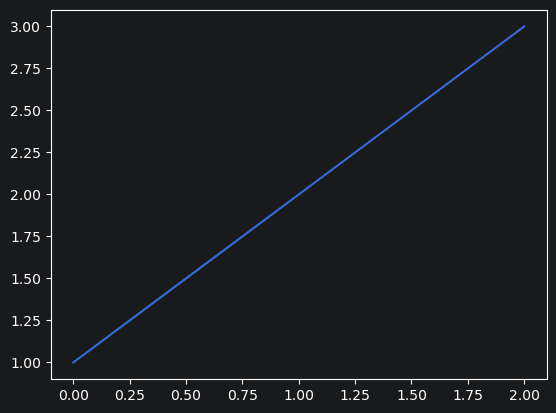

finished


In [1]:
%matplotlib inline

import matplotlib

matplotlib.rcParams['backend'] = 'module://matplotlib_inline.backend_inline'

import matplotlib.pyplot as plt

print(matplotlib.get_backend())
plt.clf()
plt.plot([1,2,3])
plt.show()
print("finished")

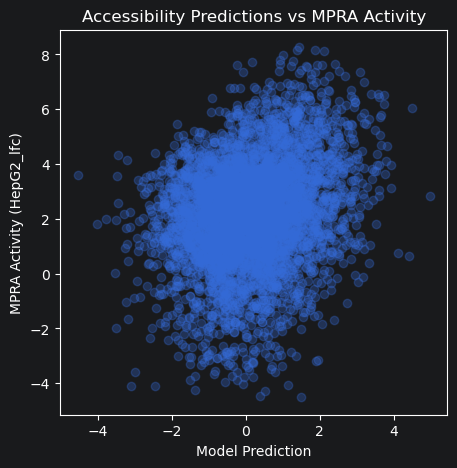

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.scatter(
    validation_df["prediction"],
    validation_df["HepG2_lfc"],
    alpha=0.3
)

plt.xlabel(
    "Model Prediction"
)

plt.ylabel(
    "MPRA Activity (HepG2_lfc)"
)

plt.title(
    "Accessibility Predictions vs MPRA Activity"
)

plt.show()

In [33]:
from scipy.stats import spearmanr

spearman_corr, spearman_p = spearmanr(
    validation_df["prediction"],
    validation_df["HepG2_lfc"]
)

print(
    f"Spearman correlation: "
    f"{spearman_corr:.4f}"
)

Spearman correlation: 0.2346


In [34]:
validation_df.to_csv(
    "../data/processed/mpra_hepg2.csv",
    index=False
)